# AI-Powered Resume Skill Analyzer

**A Data Analyst project that extracts skills from resume text, matches resumes to job roles
using TF-IDF + Cosine Similarity, and performs a skill gap analysis.**

**Dataset:** Resume Dataset (`dataset/Resume.csv`) - resumes with raw text and job category labels.

**Workflow:**
1. Load and explore the dataset
2. Clean and preprocess resume text
3. Explore the data visually (EDA)
4. Extract technical skills from each resume
5. Match resumes to sample job descriptions using TF-IDF + Cosine Similarity
6. Perform a skill gap analysis (matched vs missing skills)
7. Save the trained TF-IDF model for use in the Flask API


## 1. Import Libraries

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Text preprocessing
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Saving the model
import pickle

# Download NLTK resources (only needs to run once)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

# Plot settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully.")

ModuleNotFoundError: No module named 'wordcloud'

## 2. Load Dataset

The dataset is loaded automatically from the `dataset/` folder. It contains resume text
(`Resume_str`), the original HTML version (`Resume_html`), and the job `Category` label.

In [ ]:
# Load the dataset
df = pd.read_csv('dataset/Resume.csv')

# Basic shape
print("Shape of dataset (rows, columns):", df.shape)

Shape of dataset (rows, columns): (2484, 4)


In [ ]:
# Dataset info - column names, data types, non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   ID           2484 non-null   int64
 1   Resume_str   2484 non-null   str  
 2   Resume_html  2484 non-null   str  
 3   Category     2484 non-null   str  
dtypes: int64(1), str(3)
memory usage: 77.8 KB


In [ ]:
# Preview the first few rows
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [ ]:
# Check for missing values in each column
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64


In [ ]:
# Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())
print("Number of duplicate resumes (by Resume_str):", df.duplicated(subset=['Resume_str']).sum())

Number of duplicate rows: 0


Number of duplicate resumes (by Resume_str): 2


In [ ]:
# Basic statistics - number of unique categories and their counts
print("Number of unique job categories:", df['Category'].nunique())
print("\nResumes per category:")
print(df['Category'].value_counts())

Number of unique job categories: 24

Resumes per category:
Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
ADVOCATE                  118
CHEF                      118
FINANCE                   118
ENGINEERING               118
ACCOUNTANT                118
FITNESS                   117
AVIATION                  117
SALES                     116
HEALTHCARE                115
CONSULTANT                115
BANKING                   115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64


In [ ]:
# We only need the resume text and category for this project.
# Drop the HTML column since we already have plain text in Resume_str.
df = df[['ID', 'Resume_str', 'Category']].copy()

# Drop duplicate resumes if any
df.drop_duplicates(subset=['Resume_str'], inplace=True)
df.reset_index(drop=True, inplace=True)

print("Final dataset shape after removing duplicates:", df.shape)

Final dataset shape after removing duplicates: (2482, 3)


## 3. Data Cleaning

We clean the raw resume text so it can be used for skill extraction and TF-IDF matching.
Each step below is explained with a comment.

In [ ]:
# Load the standard English stopword list
stop_words = set(stopwords.words('english'))

# Initialize the lemmatizer (reduces words to their base/dictionary form)
lemmatizer = WordNetLemmatizer()

def clean_resume_text(text):
    """
    Cleans a single resume text string by applying:
    1. Lowercasing
    2. Removing punctuation
    3. Removing numbers
    4. Removing stopwords
    5. Removing extra whitespace
    6. Lemmatization (optional but included for cleaner keyword matching)
    """

    # Step 1: Convert everything to lowercase
    text = text.lower()

    # Step 2: Remove punctuation and special characters (keep only letters and spaces)
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Step 3: Remove standalone numbers (already mostly removed above, this is a safeguard)
    text = re.sub(r'\d+', ' ', text)

    # Step 4: Tokenize by splitting on whitespace
    words = text.split()

    # Step 5: Remove stopwords (common words like 'the', 'is', 'and' that add no value)
    words = [word for word in words if word not in stop_words]

    # Step 6: Lemmatize each word (e.g., 'developing' -> 'develop')
    words = [lemmatizer.lemmatize(word) for word in words]

    # Step 7: Join back into a single string, removing extra spaces
    cleaned_text = ' '.join(words)
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()

    return cleaned_text

In [ ]:
# Apply the cleaning function to every resume
# (This may take a little while since we are processing ~2000+ resumes)
df['Cleaned_Resume'] = df['Resume_str'].apply(clean_resume_text)

# Preview original vs cleaned text for the first resume
print("--- ORIGINAL (first 300 chars) ---")
print(df['Resume_str'].iloc[0][:300])
print("\n--- CLEANED (first 300 chars) ---")
print(df['Cleaned_Resume'].iloc[0][:300])

--- ORIGINAL (first 300 chars) ---
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commit

--- CLEANED (first 300 chars) ---
hr administrator marketing associate hr administrator summary dedicated customer service manager year experience hospitality customer service management respected builder leader customer focused team strives instill shared enthusiastic commitment customer service highlight focused customer satisfact


In [ ]:
# Add a column for resume length (word count) - useful for EDA later
df['Resume_Length'] = df['Cleaned_Resume'].apply(lambda x: len(x.split()))

df[['Category', 'Resume_Length']].head()

,Category,Resume_Length
0,HR,500
1,HR,536
2,HR,712
3,HR,262
4,HR,885


## 4. Exploratory Data Analysis (EDA)

We now visualize the dataset to understand its structure before moving to skill extraction
and job matching.

### 4.1 Category Distribution
How many resumes belong to each job category.

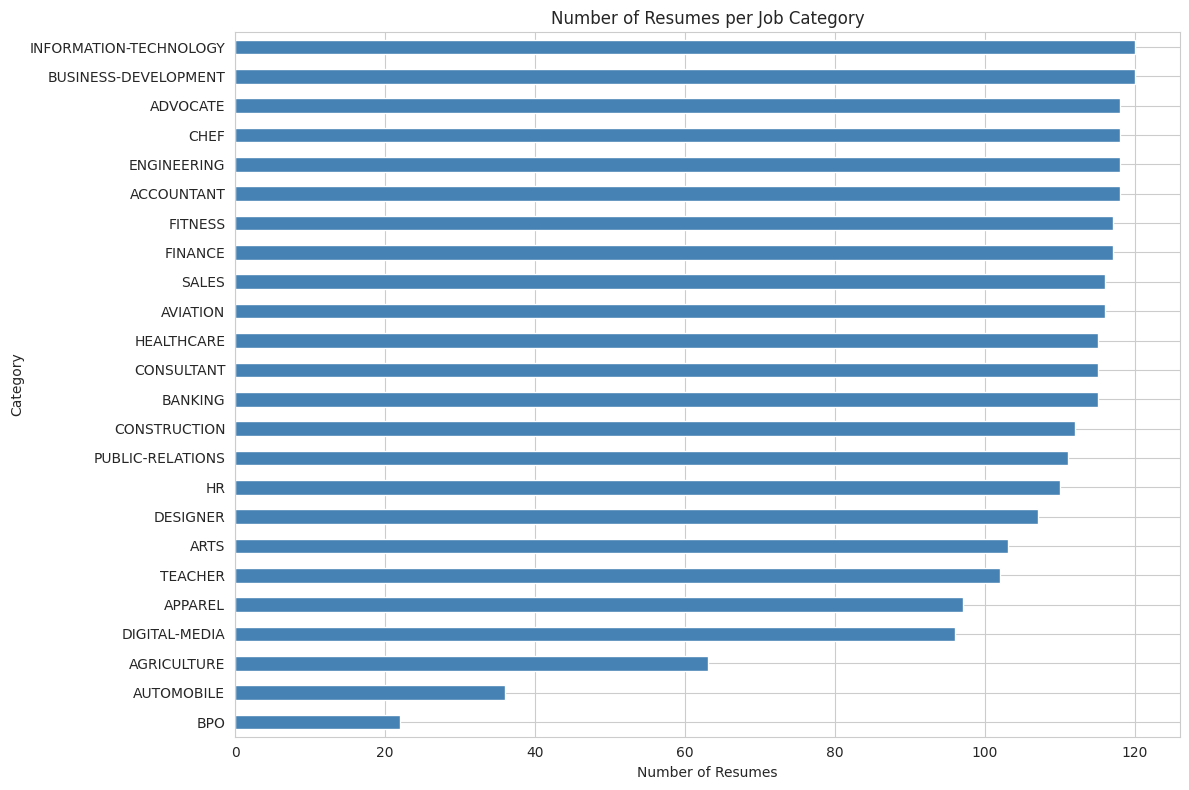

In [ ]:
plt.figure(figsize=(12, 8))
df['Category'].value_counts().plot(kind='barh', color='steelblue')
plt.title('Number of Resumes per Job Category')
plt.xlabel('Number of Resumes')
plt.ylabel('Category')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Insight:** Some categories (e.g., Information Technology, Business Development) have far more resumes than others (e.g., BPO, Automobile) - the dataset is imbalanced across categories.

### 4.2 Resume Length Distribution
How long resumes are, in terms of word count after cleaning.

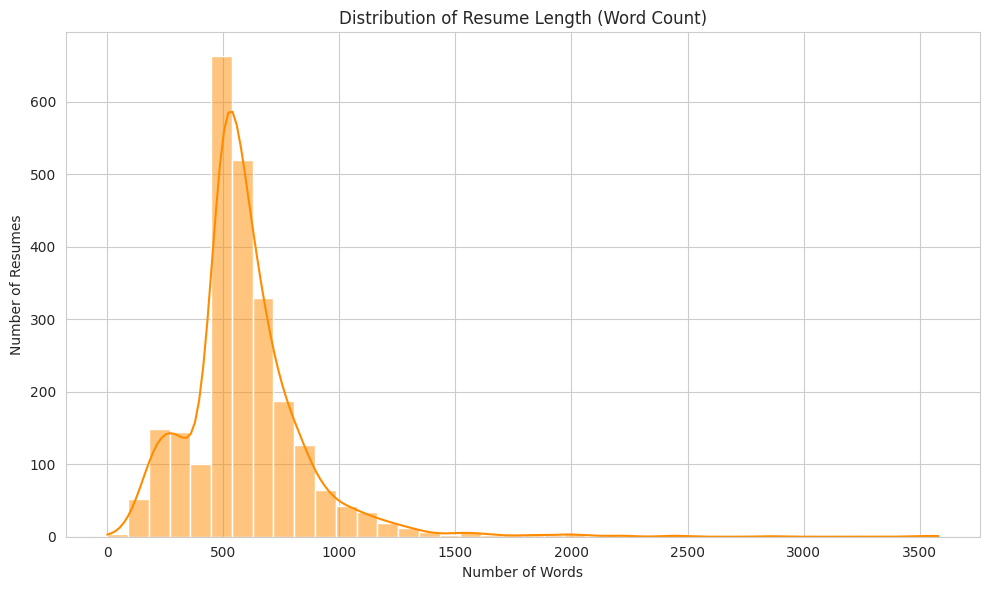

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Resume_Length'], bins=40, kde=True, color='darkorange')
plt.title('Distribution of Resume Length (Word Count)')
plt.xlabel('Number of Words')
plt.ylabel('Number of Resumes')
plt.tight_layout()
plt.show()

**Insight:** Most resumes fall within a common word-count range, with a few much longer outliers (likely resumes with extensive work history).

### 4.3 Average Resume Length by Category
Which job categories tend to have longer resumes.

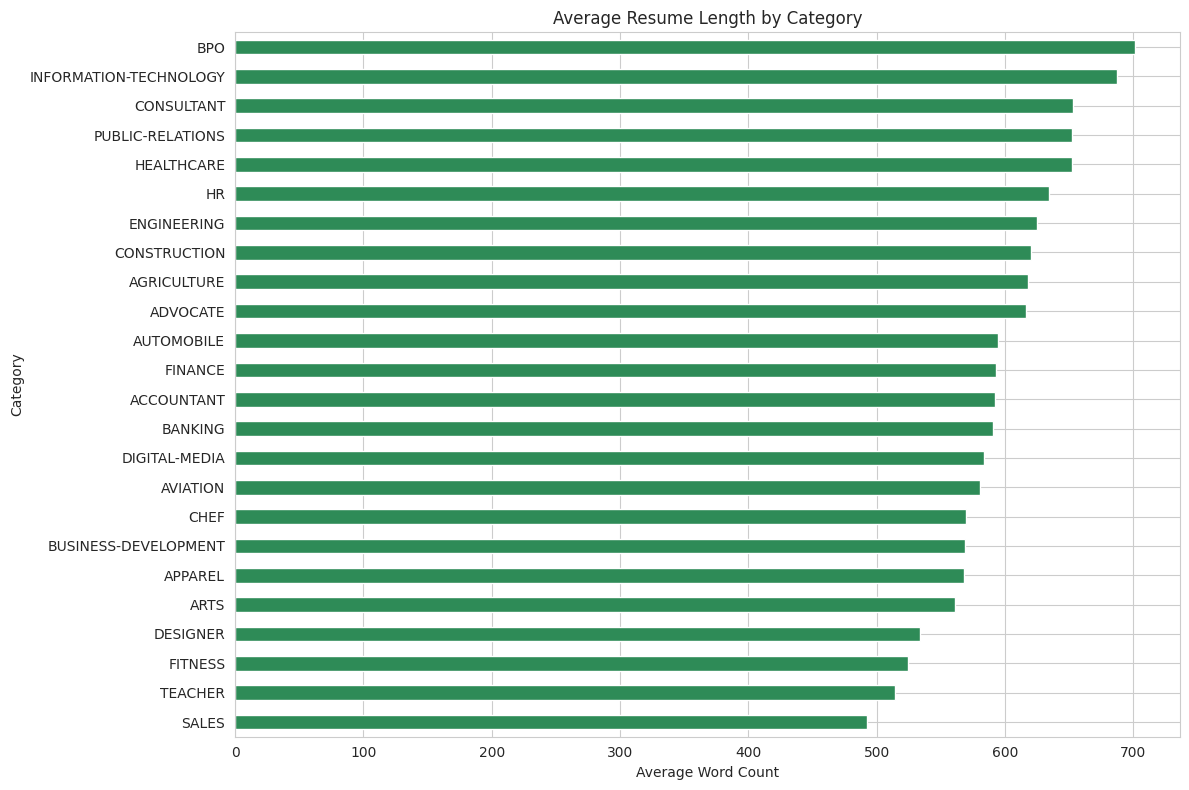

In [ ]:
avg_len = df.groupby('Category')['Resume_Length'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
avg_len.plot(kind='barh', color='seagreen')
plt.title('Average Resume Length by Category')
plt.xlabel('Average Word Count')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Insight:** Categories like Engineering or Healthcare may have longer resumes on average due to certifications and detailed experience sections.

### 4.4 Word Cloud of All Resumes
The most frequently occurring words across every resume.

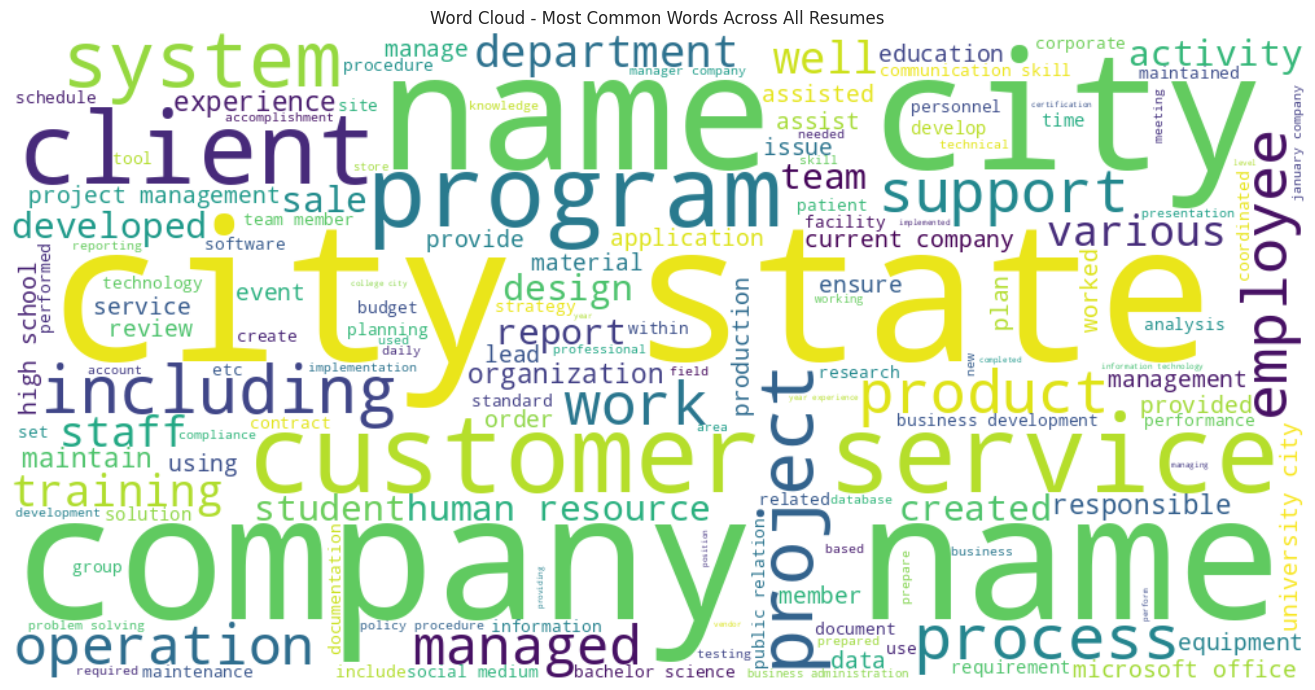

In [ ]:
all_text = ' '.join(df['Cleaned_Resume'])

wordcloud = WordCloud(width=1000, height=500, background_color='white',
                       colormap='viridis', max_words=150).generate(all_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Most Common Words Across All Resumes')
plt.tight_layout()
plt.show()

**Insight:** Generic resume/business terms dominate; this motivates the need for a focused technical-skill extraction step (Section 5) rather than relying on raw word frequency.

### 4.5 Top 20 Most Frequent Words (excluding generic terms)

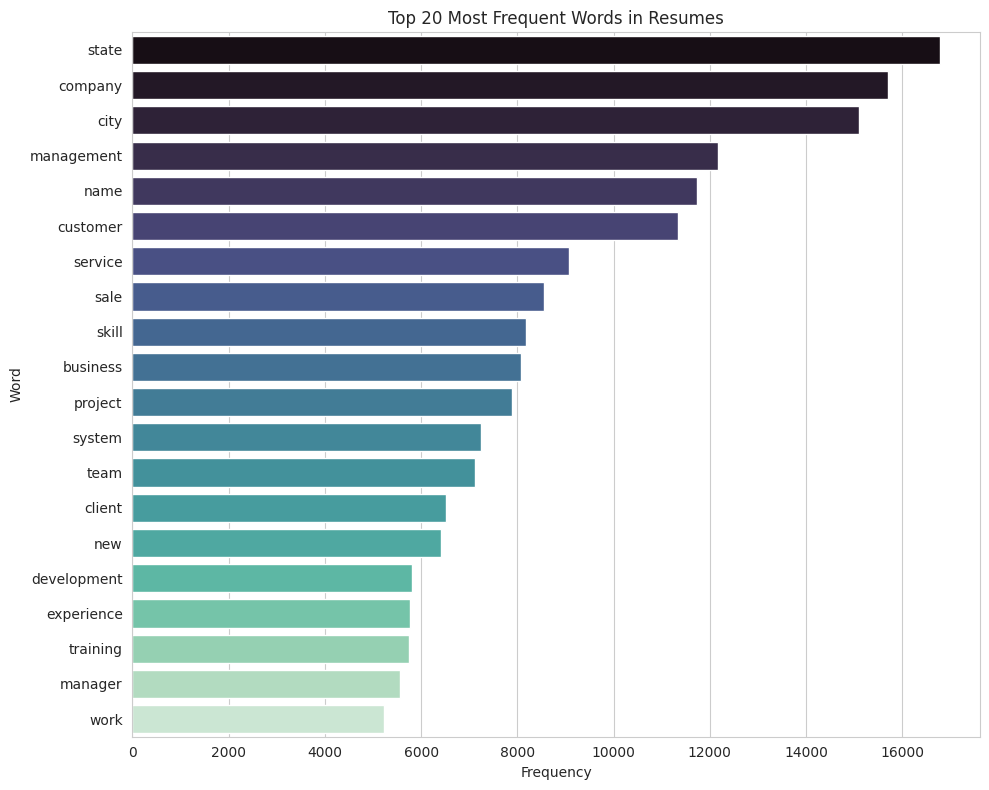

In [ ]:
from collections import Counter

all_words = all_text.split()
word_freq = Counter(all_words)
top_words = pd.DataFrame(word_freq.most_common(20), columns=['Word', 'Frequency'])

plt.figure(figsize=(10, 8))
sns.barplot(data=top_words, x='Frequency', y='Word', hue='Word', palette='mako', legend=False)
plt.title('Top 20 Most Frequent Words in Resumes')
plt.tight_layout()
plt.show()

**Insight:** These top keywords give a first impression of common resume vocabulary before we narrow down to specific technical skills.

### 4.6 Resume Count vs Average Length (Top 10 Categories)
Comparing volume and depth of resumes for the largest categories.

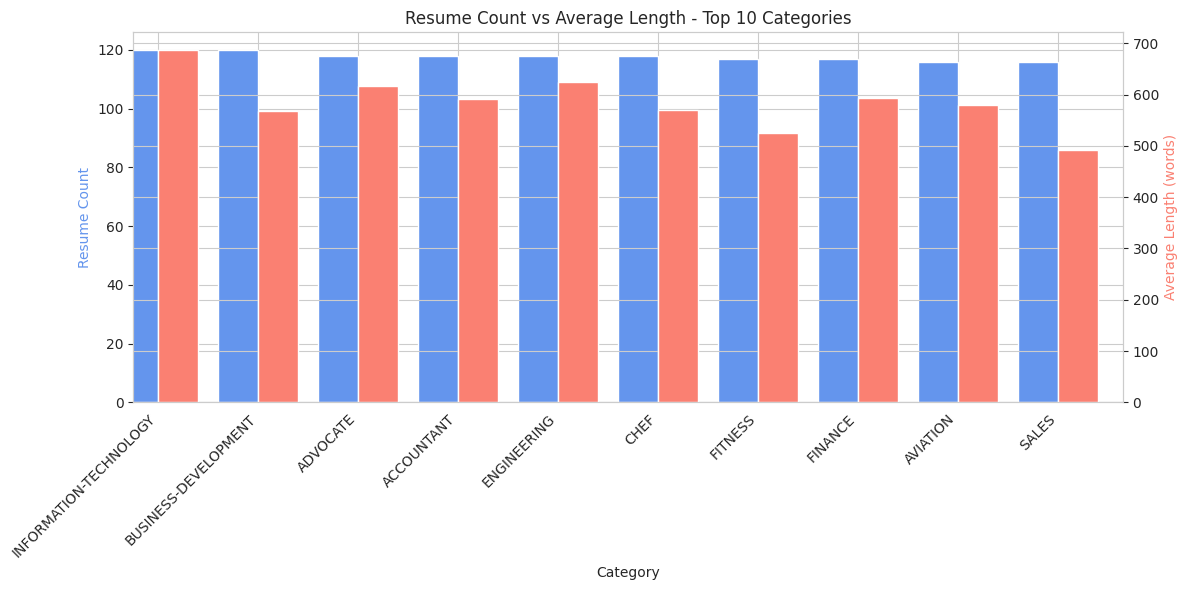

In [ ]:
top10_cat = df['Category'].value_counts().head(10).index
top10_df = df[df['Category'].isin(top10_cat)]

summary = top10_df.groupby('Category').agg(
    Resume_Count=('Category', 'count'),
    Avg_Length=('Resume_Length', 'mean')
).sort_values('Resume_Count', ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

summary['Resume_Count'].plot(kind='bar', ax=ax1, color='cornflowerblue', position=1, width=0.4)
summary['Avg_Length'].plot(kind='bar', ax=ax2, color='salmon', position=0, width=0.4)

ax1.set_ylabel('Resume Count', color='cornflowerblue')
ax2.set_ylabel('Average Length (words)', color='salmon')
ax1.set_xticklabels(summary.index, rotation=45, ha='right')
plt.title('Resume Count vs Average Length - Top 10 Categories')
plt.tight_layout()
plt.show()

**Insight:** Categories with more resumes don't necessarily have longer resumes - volume and depth vary independently.

### 4.7 Boxplot of Resume Length by Top 6 Categories
Spread and outliers in resume length within each category.

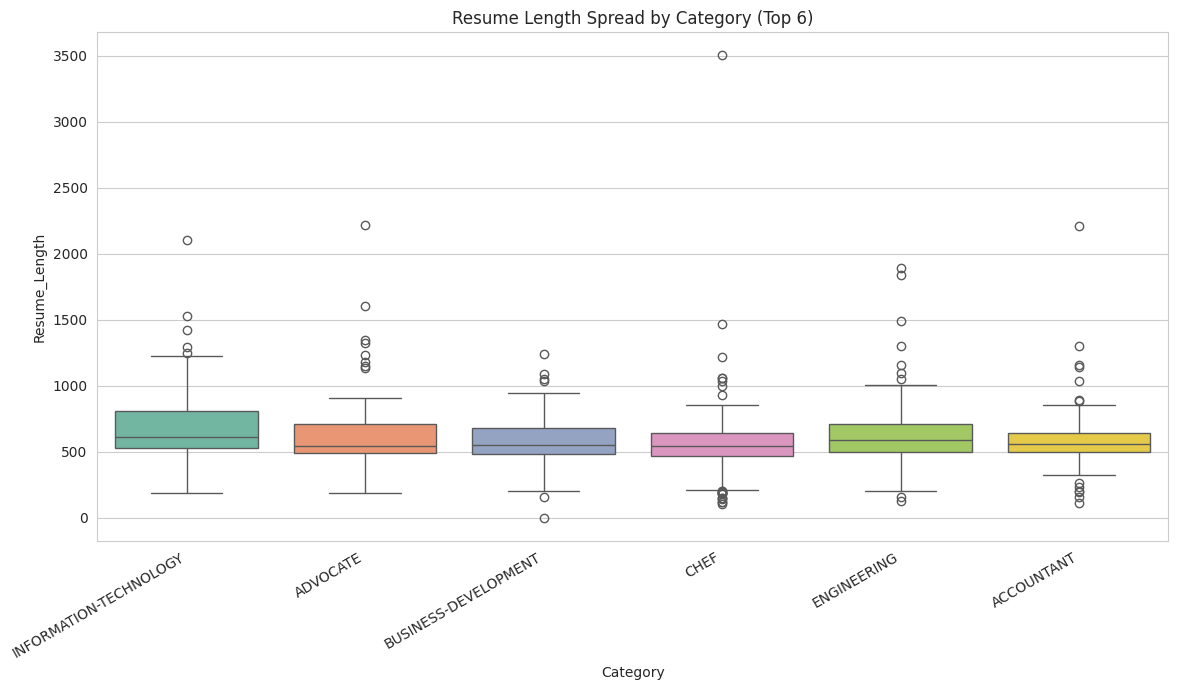

In [ ]:
top6_cat = df['Category'].value_counts().head(6).index
top6_df = df[df['Category'].isin(top6_cat)]

plt.figure(figsize=(12, 7))
sns.boxplot(data=top6_df, x='Category', y='Resume_Length', hue='Category', palette='Set2', legend=False)
plt.title('Resume Length Spread by Category (Top 6)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Insight:** Boxplots reveal categories with wide variation in resume length versus categories where resumes are more consistent in size.

### 4.8 Number of Categories with Fewer than 100 Resumes
Highlighting underrepresented categories in the dataset.

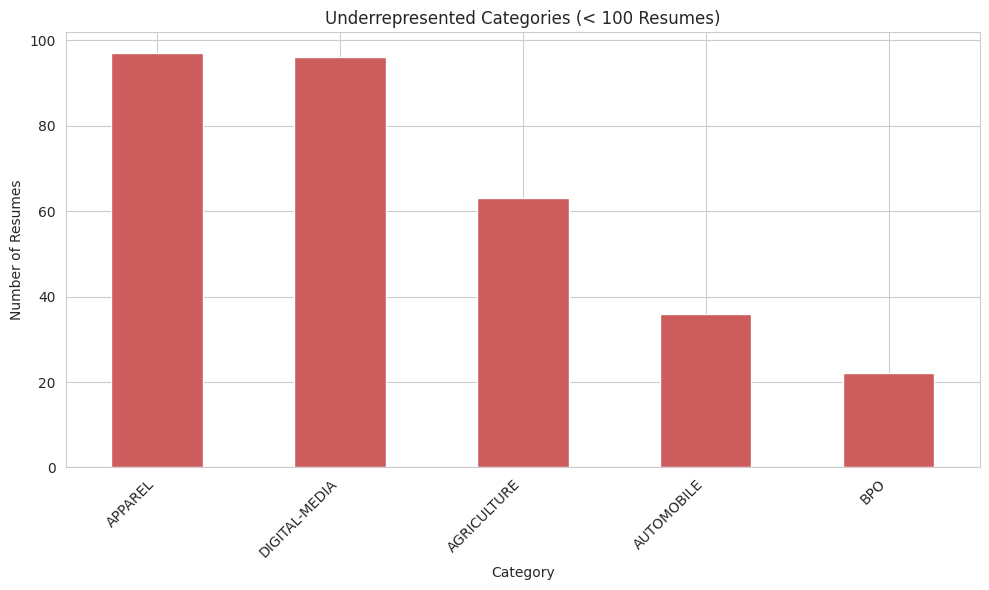

5 out of 24 categories have fewer than 100 resumes.


In [ ]:
cat_counts = df['Category'].value_counts()
low_rep = cat_counts[cat_counts < 100]

plt.figure(figsize=(10, 6))
low_rep.plot(kind='bar', color='indianred')
plt.title('Underrepresented Categories (< 100 Resumes)')
plt.ylabel('Number of Resumes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"{len(low_rep)} out of {df['Category'].nunique()} categories have fewer than 100 resumes.")

**Insight:** A handful of categories are underrepresented, which is worth keeping in mind if this dataset were later used for a classification model.

## 5. Skill Extraction

We search each cleaned resume for a predefined list of common technical/analytical skills
and store the ones found in a new `Extracted_Skills` column.

In [ ]:
# List of common technical skills relevant to Data/Business Analyst roles
SKILL_KEYWORDS = [
    'python', 'sql', 'excel', 'power bi', 'tableau', 'machine learning',
    'pandas', 'numpy', 'scikit learn', 'statistics', 'git', 'linux',
    'communication', 'data analysis', 'data visualization', 'r programming',
    'java', 'aws', 'azure', 'nlp', 'deep learning', 'etl', 'database'
]

# Note: multi-word skills (like "power bi") need slight handling since our
# cleaned text already removed punctuation, so we search for the joined phrase.
def extract_skills(text):
    """Searches the cleaned resume text for known skill keywords and returns a list of matches."""
    found_skills = []
    for skill in SKILL_KEYWORDS:
        # Build a simple regex pattern that matches the skill as a whole phrase
        pattern = r'\b' + re.escape(skill) + r'\b'
        if re.search(pattern, text):
            found_skills.append(skill)
    return found_skills

df['Extracted_Skills'] = df['Cleaned_Resume'].apply(extract_skills)
df['Skill_Count'] = df['Extracted_Skills'].apply(len)

df[['Category', 'Extracted_Skills', 'Skill_Count']].head(10)

,Category,Extracted_Skills,Skill_Count
0,HR,[data analysis],1
1,HR,[communication],1
2,HR,"[excel, database]",2
3,HR,"[excel, communication, database]",3
4,HR,[excel],1
5,HR,"[excel, database]",2
6,HR,[],0
7,HR,"[communication, database]",2
8,HR,"[excel, communication]",2
9,HR,[database],1


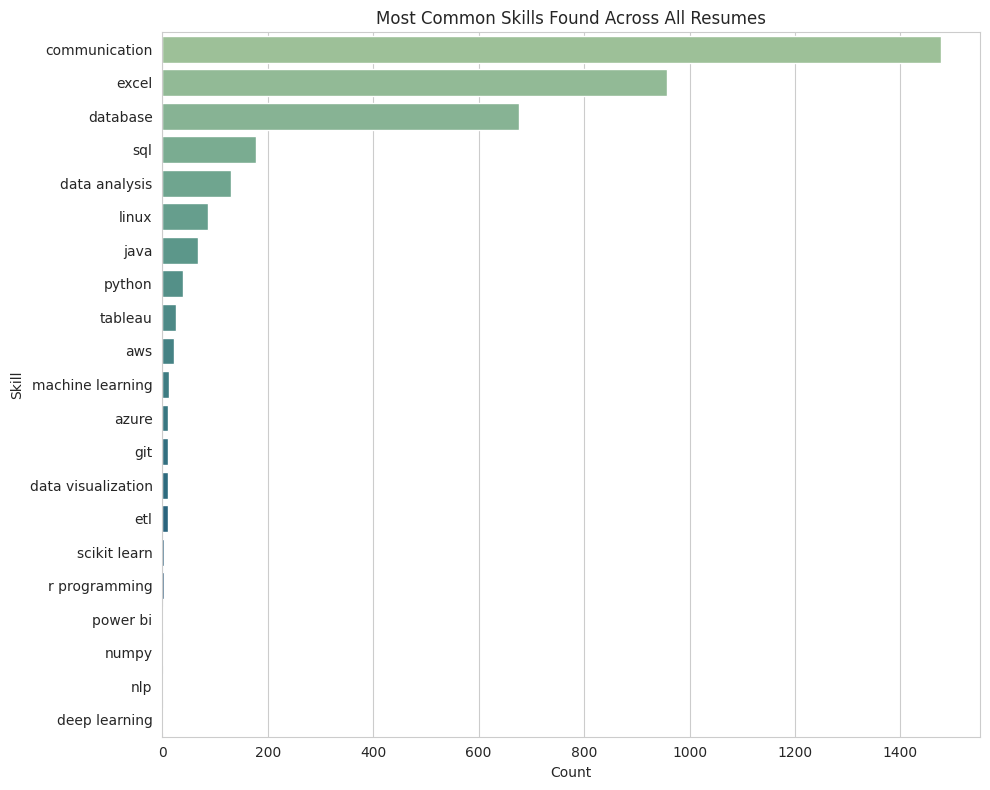

In [ ]:
# Visualize the most commonly found skills across all resumes
all_skills = [skill for skills in df['Extracted_Skills'] for skill in skills]
skill_freq = Counter(all_skills)
skill_df = pd.DataFrame(skill_freq.most_common(), columns=['Skill', 'Count'])

plt.figure(figsize=(10, 8))
sns.barplot(data=skill_df, x='Count', y='Skill', hue='Skill', palette='crest', legend=False)
plt.title('Most Common Skills Found Across All Resumes')
plt.tight_layout()
plt.show()

**Insight:** Skills like communication, data analysis, and Excel appear frequently across many resume categories, while tools like Power BI or Tableau are more specialized and appear less often.

## 6. Resume Matching (TF-IDF + Cosine Similarity)

We create a set of ~20 sample job descriptions and use TF-IDF vectorization with cosine
similarity to recommend the best-fit job roles for a given resume.

In [ ]:
# Sample job descriptions for common Data/Analytics/Tech roles
job_descriptions = {
    "Data Analyst": "python sql excel power bi tableau data analysis data visualization statistics pandas numpy communication",
    "Business Analyst": "excel sql communication data analysis stakeholder management power bi requirements gathering statistics",
    "Python Developer": "python git linux database api development object oriented programming debugging",
    "Machine Learning Engineer": "python machine learning scikit learn numpy pandas deep learning statistics model deployment",
    "Data Scientist": "python r programming machine learning statistics data visualization deep learning sql pandas numpy",
    "Power BI Developer": "power bi dax data visualization sql excel data modeling etl reporting",
    "SQL Developer": "sql database etl data warehousing query optimization stored procedures",
    "AI Engineer": "python machine learning deep learning nlp tensorflow model deployment statistics",
    "ETL Developer": "etl sql database data warehousing python data pipeline aws",
    "Software Engineer": "java python git linux software development debugging database object oriented programming",
    "Data Engineer": "python sql etl aws database data pipeline data warehousing",
    "BI Analyst": "power bi tableau sql excel data visualization dax reporting statistics",
    "Statistical Analyst": "statistics python r programming data analysis excel data visualization",
    "Cloud Engineer": "aws azure linux database git cloud infrastructure",
    "Database Administrator": "sql database linux etl data warehousing query optimization",
    "Research Analyst": "excel statistics data analysis communication python data visualization",
    "NLP Engineer": "python nlp machine learning deep learning data analysis statistics",
    "DevOps Engineer": "linux git aws azure automation database",
    "Reporting Analyst": "excel power bi tableau data visualization sql communication",
    "Junior Data Analyst": "excel sql python data analysis communication statistics"
}

print(f"Total job descriptions created: {len(job_descriptions)}")

Total job descriptions created: 20


In [ ]:
# Combine resumes and job descriptions into a single corpus for TF-IDF fitting
job_titles = list(job_descriptions.keys())
job_texts = list(job_descriptions.values())

# Fit TF-IDF on the job descriptions (this becomes our reference vocabulary/vector space)
tfidf_vectorizer = TfidfVectorizer()
job_vectors = tfidf_vectorizer.fit_transform(job_texts)

print("TF-IDF vectorizer fitted on job descriptions.")
print("Vocabulary size:", len(tfidf_vectorizer.vocabulary_))

TF-IDF vectorizer fitted on job descriptions.
Vocabulary size: 52


In [ ]:
def match_resume_to_jobs(resume_text, top_n=3):
    """
    Takes a cleaned resume text, transforms it using the fitted TF-IDF vectorizer,
    and returns the top_n best-matching job roles with their similarity scores.
    """
    resume_vector = tfidf_vectorizer.transform([resume_text])
    similarities = cosine_similarity(resume_vector, job_vectors)[0]

    # Get indices of the top N most similar job descriptions
    top_indices = similarities.argsort()[::-1][:top_n]

    results = [(job_titles[i], round(similarities[i] * 100, 2)) for i in top_indices]
    return results

# Test on the first resume in the dataset
sample_resume = df['Cleaned_Resume'].iloc[0]
top_matches = match_resume_to_jobs(sample_resume)

print("Category (ground truth):", df['Category'].iloc[0])
print("\nTop 3 Job Matches:")
for job, score in top_matches:
    print(f"  {job}: {score}%")

Category (ground truth): HR

Top 3 Job Matches:
  Business Analyst: 42.14%
  Statistical Analyst: 18.37%
  Power BI Developer: 14.38%


In [ ]:
# Apply matching to a sample of 10 resumes to see overall results
sample_df = df.sample(10, random_state=42).copy()
sample_df['Top_Match'] = sample_df['Cleaned_Resume'].apply(lambda x: match_resume_to_jobs(x, top_n=1)[0][0])
sample_df['Match_Score'] = sample_df['Cleaned_Resume'].apply(lambda x: match_resume_to_jobs(x, top_n=1)[0][1])

sample_df[['Category', 'Top_Match', 'Match_Score']]

,Category,Top_Match,Match_Score
254,INFORMATION-TECHNOLOGY,Software Engineer,36.66
621,BUSINESS-DEVELOPMENT,Business Analyst,35.42
1730,ENGINEERING,Business Analyst,40.25
1792,ENGINEERING,Business Analyst,42.85
819,FITNESS,Business Analyst,34.56
1583,FINANCE,Junior Data Analyst,41.21
879,FITNESS,Python Developer,35.60
1414,CHEF,Business Analyst,46.57
2164,BANKING,Business Analyst,39.38
497,ADVOCATE,Software Engineer,36.29


## 7. Skill Gap Analysis

For a given resume and target job role, we compare the skills required for that role against
the skills found in the resume, highlighting matched skills, missing skills, and a match percentage.

In [ ]:
# Define required skills for each job role (subset of SKILL_KEYWORDS relevant to that role)
required_skills_map = {
    "Data Analyst": ['python', 'sql', 'excel', 'power bi', 'tableau', 'data analysis', 'statistics'],
    "Business Analyst": ['excel', 'sql', 'communication', 'data analysis', 'power bi'],
    "Python Developer": ['python', 'git', 'linux', 'database'],
    "Machine Learning Engineer": ['python', 'machine learning', 'scikit learn', 'numpy', 'pandas', 'statistics'],
    "Data Scientist": ['python', 'machine learning', 'statistics', 'data visualization', 'sql'],
    "Power BI Developer": ['power bi', 'data visualization', 'sql', 'excel'],
    "SQL Developer": ['sql', 'database', 'etl'],
    "AI Engineer": ['python', 'machine learning', 'deep learning', 'statistics'],
    "ETL Developer": ['etl', 'sql', 'database', 'python'],
    "Software Engineer": ['java', 'python', 'git', 'database'],
}

def skill_gap_analysis(resume_skills, target_job):
    """
    Compares the resume's extracted skills against the required skills for a target job.
    Returns matched skills, missing skills, and a match percentage.
    """
    required = set(required_skills_map.get(target_job, []))
    have = set(resume_skills)

    matched = sorted(required & have)
    missing = sorted(required - have)
    match_percent = round((len(matched) / len(required)) * 100, 2) if required else 0.0

    return matched, missing, match_percent

In [ ]:
# Example: run a skill gap analysis for the first resume against its top-matched job
sample_index = 0
resume_skills = df['Extracted_Skills'].iloc[sample_index]
top_job = match_resume_to_jobs(df['Cleaned_Resume'].iloc[sample_index], top_n=1)[0][0]

matched, missing, match_pct = skill_gap_analysis(resume_skills, top_job)

print(f"Target Job: {top_job}")
print(f"Matched Skills: {matched}")
print(f"Missing Skills: {missing}")
print(f"Match Percentage: {match_pct}%")

if missing:
    print(f"\nRecommendation: Consider learning/highlighting {', '.join(missing)} to improve fit for the '{top_job}' role.")
else:
    print("\nRecommendation: Resume covers all key required skills for this role.")

Target Job: Business Analyst
Matched Skills: ['data analysis']
Missing Skills: ['communication', 'excel', 'power bi', 'sql']
Match Percentage: 20.0%

Recommendation: Consider learning/highlighting communication, excel, power bi, sql to improve fit for the 'Business Analyst' role.


## 8. Save Model

We save the fitted TF-IDF vectorizer, the job description vectors, and supporting data so the
Flask API (`app.py`) can load them without retraining.

In [ ]:
model_artifacts = {
    'vectorizer': tfidf_vectorizer,
    'job_vectors': job_vectors,
    'job_titles': job_titles,
    'skill_keywords': SKILL_KEYWORDS,
    'required_skills_map': required_skills_map
}

with open('model.pkl', 'wb') as f:
    pickle.dump(model_artifacts, f)

print("Model artifacts saved to model.pkl")

Model artifacts saved to model.pkl


In [ ]:
# Also save the job descriptions as a standalone CSV (matches the project's file structure)
job_desc_df = pd.DataFrame({
    'Job_Title': job_titles,
    'Job_Description': job_texts
})
job_desc_df.to_csv('job_descriptions.csv', index=False)

print("Job descriptions saved to job_descriptions.csv")
job_desc_df.head()

Job descriptions saved to job_descriptions.csv


,Job_Title,Job_Description
0,Data Analyst,python sql excel power bi tableau data analysi...
1,Business Analyst,excel sql communication data analysis stakehol...
2,Python Developer,python git linux database api development obje...
3,Machine Learning Engineer,python machine learning scikit learn numpy pan...
4,Data Scientist,python r programming machine learning statisti...


## 9. Flask REST API

The Flask REST API is implemented separately in **`app.py`** (kept outside the notebook so it
can run as a standalone service). It loads `model.pkl` and exposes two endpoints:

- `GET /` - health check, returns a running message.
- `POST /predict` - accepts `{"resume_text": "..."}` and returns the top job match, top 3
  recommendations, matched skills, and missing skills as JSON.

**To run the API:**
```bash
python app.py
```

See `README.md` for full usage instructions and a sample request/response.

## Conclusion

This notebook built a complete, lightweight pipeline for analyzing resumes:

- Cleaned and preprocessed raw resume text
- Explored the dataset through 8 visualizations
- Extracted technical skills using keyword matching
- Matched resumes to job roles using TF-IDF + Cosine Similarity
- Performed a skill gap analysis with actionable recommendations
- Saved the trained model for use in a lightweight Flask REST API

**Future Improvements:**
- Expand the skill keyword list and job description set
- Use a trained NER model for more robust skill extraction
- Add resume-category classification as a secondary model
- Deploy the Flask API behind a simple web form for non-technical users
